## Agent WorkFlow Example

In [1]:
import os
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def get_weather(city:str)-> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent

response = agent.invoke({"messages":[{"role":"user","content":"What is the weather in chennai?"}]})
response["messages"][-1].content

'The weather in Chennai is sunny.'

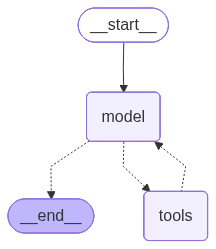

In [2]:

agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)
agent


## Models Integration with OpenAI,Google,Gemini and Groq

In [3]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

#model1 = init_chat_model(model="gpt-4.1",model_provider-"openai")
#model1
#response1 = model1.invoke("Hello How are you?")
#response1

model2 = init_chat_model(model="gemini-2.5-flash",model_provider="google_genai")
model2
response2 = model2.invoke("Why do parrots talk?")
response2.content

model3 = init_chat_model(model="llama-3.3-70b-versatile",model_provider="groq")
model3
response3 = model3.invoke("Who am i?")
response3


AIMessage(content="Unfortunately, I don't have any information about you, so I'll have to ask some questions to try to figure out who you are.\n\nTo start, are you a person, a character, or something else entirely?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 39, 'total_tokens': 84, 'completion_time': 0.149140123, 'completion_tokens_details': None, 'prompt_time': 0.006724095, 'prompt_tokens_details': None, 'queue_time': 0.051045824, 'total_time': 0.155864218}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0375-19b8-7811-9f18-8279caaa4130-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 45, 'total_tokens': 84})

## Streaming 
Most model can stream their output while it is being generated. By displaying output progressive,streaming significantly improves user experience,particularly for longer responses. Calling stream() return an iterator that yeild output chunks as they are produced. You can use a loop to process each chunk in real-time.

In [7]:
for chunk in model2.stream("Write me a 200 words paragraph on Artificial Intelligence"):
    print(chunk.text, end="|", flush=True)

for chunk in model2.stream("Why do parrots have colorful features?"):
    print(chunk.text, end="|", flush=True)

Artificial Intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think, learn, and problem|-solve like humans. This rapidly evolving field encompasses a broad range of technologies, from machine learning and deep learning to natural language processing and computer vision, enabling systems to perform tasks that traditionally required human cognitive abilities. Modern AI excels at processing vast amounts of data|, identifying complex patterns, and making predictions or decisions with remarkable accuracy.

Its applications are profoundly transforming nearly every sector worldwide. In healthcare, AI aids in diagnosis, drug discovery, and personalized treatment plans. In finance, it powers algorithmic trading,| fraud detection, and risk assessment. Autonomous vehicles, smart assistants, recommendation engines, and sophisticated cybersecurity systems are just a few examples of AI’s pervasive presence in our daily lives, enhancing efficiency, inn

## Batch
BAtching a collection of independent requests to a model can significantly improve performance and reduce cost, as the processing can be done in parallel.

In [6]:
responses = model2.batch([
    "Why do parrots have colorful features?",
    "How do airplane fly?",
    "what is quantum computing?"
])
for res in responses:
    print(res)

model2.batch([
    "Why do parrots have colorful features?",
    "How do airplane fly?",
    "what is quantum computing?"
],
config={
    'max_concurrency':5
}
)

content='Parrots are renowned for their vibrant and diverse plumage, and this stunning coloration serves a variety of important evolutionary purposes, stemming from a combination of biological mechanisms:\n\n### How They Get Their Colors:\n\n1.  **Pigments:**\n    *   **Melanins:** Produce blacks, browns, and grays. These are produced by the bird\'s own body.\n    *   **Carotenoids:** Produce reds, yellows, and oranges. These pigments cannot be synthesized by the bird and must be obtained through their diet (e.g., from fruits, seeds, and nectar). The availability of carotenoids in their diet directly influences the brightness and intensity of these colors, making them a "honest signal" of health and foraging ability.\n    *   **Psittacofulvins:** Unique to parrots, these pigments produce a range of reds, oranges, and yellows. Unlike carotenoids, psittacofulvins are synthesized by the parrots themselves.\n\n2.  **Structural Colors:**\n    *   **Blues and Greens:** These colors are not d

[AIMessage(content='Parrots are renowned for their stunning, vibrant plumage, and this riot of color serves several important evolutionary purposes and is achieved through fascinating biological mechanisms:\n\n1.  **Sexual Selection and Attracting Mates:**\n    *   **"Good Genes" Hypothesis:** One of the primary reasons is to signal health, vigor, and genetic fitness to potential mates. Brighter, more vibrant, and well-maintained feathers indicate that a parrot is good at finding food (which influences pigment production), is free from parasites, and has a strong immune system.\n    *   **Mate Choice:** In many parrot species, females will choose males with the most impressive and colorful displays, ensuring healthier offspring. Even in species where both sexes are colorful, the intensity or specific patterns can still play a role in mutual assessment.\n\n2.  **Camouflage (Surprisingly!):**\n    *   While counter-intuitive, bright colors can actually provide effective camouflage in the

## Tools
Model can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairing of:  
                1. A schema,include tha name of the tool, a description, and/or argument definition(often a JSON schema)  
    2.A function or coroutine to execute.

In [8]:
import os
from langchain.chat_models import init_chat_model
from langchain.tools import tool

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("Why do parrots talk?")
print(response)

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    return f"It's sunny in {location}"
model_with_tools=model.bind_tools([get_weather])


response = model_with_tools.invoke("What's the weather like in Boston?")
print(response)
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

# Step 1: Model generates tool calls
messages = [{"role": "user", "content": "What's the weather in Boston?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)
# "The current weather in Boston is 72°F and sunny."

content='<think>\nOkay, so the user is asking why parrots talk. Let me start by recalling what I know about parrots. They\'re known for their ability to mimic human speech, right? I think it\'s related to their natural behavior. In the wild, parrots use their vocalizations to communicate with each other. Maybe talking is an extension of that. \n\nFirst, I should consider their social structure. Parrots are highly social animals. They live in flocks, so communication is crucial for them. They might mimic sounds to bond with their flock or to learn from each other. If they\'re in captivity, they might direct that behavior towards humans. \n\nThen there\'s the aspect of learning. Parrots have a part of their brain similar to humans that\'s involved in vocal learning. That must be important. They probably learn by listening and repeating, just like humans do when learning to speak. But how exactly does that work? Do they have a specific mechanism for this?\n\nI remember reading something a

# Messages

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM.

Messages are objects that contain:

- **Role** – Identifies the message type (e.g., system, user).
- **Content** – Represents the actual content of the message (such as text, images, audio, documents, etc.).
- **Metadata** – Optional fields such as response information, message IDs, and token usage.

LangChain provides a standard message type that works across all model providers, ensuring consistent behavior regardless of the model being called.

# Message Prompts

Alternatively, you can pass a list of messages to the model by providing a list of message objects.

## Message Types

- **System Message** – Tells the model how to behave and provides context for interactions.
- **Human Message** – Represents user input and interactions with the model.
- **AI Message** – Responses generated by the model, including text content, tool calls, and metadata.
- **Tool Message** – Represents the outputs of tool calls.

## System Message

A `SystemMessage` represents an initial set of instructions that primes the model's behavior. You can use a system message to set the tone, define the model's role, and establish guidelines for responses.

## Human Message

A `HumanMessage` represents user input and interactions. It can contain text, images, audio, files, and other types of multimodal content.

## AI Message

An `AIMessage` represents the output of a model invocation. It can include multimodal data, tool calls, and provider-specific metadata that you can later access.

## Tool Message

For models that support tool calling, AI messages can contain tool calls. `ToolMessage` objects are used to pass the results of a single tool execution back to the model.

In [1]:
import os
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage,AIMessage,ToolMessage

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")

messages=[
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a poem on artificial intelligence")
]
response=model.invoke(messages)
print(response.content)


ai_message = AIMessage(
    content=[],
    tool_calls=[{
        "name": "get_weather",
        "args": {"location": "San Francisco"},
        "id": "call_123"
    }]
)

# Execute tool and create result message
weather_result = "Sunny, 72°F"
tool_message = ToolMessage(
    content=weather_result,
    tool_call_id="call_123"  # Must match the call ID
)

# Continue conversation
messages = [
    HumanMessage("What's the weather in San Francisco?"),
    ai_message,  # Model's tool call
    tool_message,  # Tool execution result
]
response = model.invoke(messages)
print(response)

response.usage_metadata



<think>
Okay, the user wants a poem about artificial intelligence. Let me start by brainstorming some key themes related to AI. There's the creation aspect—how humans build AI, the blend of code and circuits. Then there's the duality of AI: it can be helpful but also raises concerns. Maybe touch on the rapid advancements and the ethical questions.

I should consider the structure. Maybe a traditional rhyme scheme to give it a classic feel, contrasting with the modern topic. Let me think of some imagery: circuits like veins, data flowing, neural networks. Personification might work well here, giving AI human-like qualities but also showing its artificial nature.

I need to balance the positive and negative aspects. Highlighting AI's role in solving problems, but also the fear it might evoke. Perhaps end with a reflection on the relationship between humans and AI, emphasizing collaboration rather than conflict. Words like "synthetic soul" or "ghost in the machine" could add depth. Let me

{'input_tokens': 57, 'output_tokens': 184, 'total_tokens': 241}